# Tutorial: LangGraph en Python

Este cuaderno introduce LangGraph con ejemplos sencillos de grafos y agentes. Usa el entorno `AIAerospace` y la API de OpenAI.

LangGraph permite definir aplicaciones con LLM como grafos de estado: cada nodo hace una parte del trabajo, las aristas definen el flujo y el estado compartido conecta todo el proceso.

Contenidos:

- Conceptos basicos: estado, nodos, aristas y compilacion.
- Un grafo determinista sin LLM.
- Una estructura simple de agentes: planificador, investigador, redactor y revisor.
- Un bucle de revision con condicion de parada.
- Un agente con herramientas usando `ToolNode`.
- Memoria corta con checkpointer.

Referencias oficiales: [LangGraph quickstart](https://docs.langchain.com/oss/python/langgraph/quickstart), [overview](https://docs.langchain.com/oss/python/langgraph/overview) y [ToolNode](https://reference.langchain.com/python/langgraph/agents/#langgraph.prebuilt.tool_node.ToolNode).

## 1. Preparacion

Antes de ejecutar el cuaderno, activa el entorno `AIAerospace` y define `OPENAI_API_KEY`.

```powershell
conda activate AIAerospace
$env:OPENAI_API_KEY="sk-..."
jupyter lab
```

El modelo se centraliza en `MODEL` para poder cambiarlo facilmente.

In [6]:
import os
import textwrap
from typing import Literal
from typing_extensions import TypedDict

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.tools import tool
from pydantic import BaseModel, Field

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import InMemorySaver

MODEL = os.getenv("OPENAI_MODEL", "gpt-5.4-nano")
llm = ChatOpenAI(model=MODEL, temperature=0.2)

def show(text, width=95):
    print(textwrap.fill(str(text), width=width))

print("Modelo:", MODEL)

Modelo: gpt-5.4-nano


## 2. Conceptos basicos

Un grafo de LangGraph tiene tres piezas principales:

- Estado: datos compartidos por los nodos.
- Nodos: funciones que leen el estado y devuelven actualizaciones.
- Aristas: conexiones que indican que nodo se ejecuta despues.

Primero hacemos un grafo determinista sin llamadas a modelos.

In [7]:
class SimpleState(TypedDict, total=False):
    question: str
    route: Literal["rag", "chat"]
    answer: str

def classify_question(state: SimpleState):
    question = state["question"].lower()
    if "boe" in question or "documento" in question or "pdf" in question:
        return {"route": "rag"}
    return {"route": "chat"}

def answer_with_rag_placeholder(state: SimpleState):
    return {"answer": "Ruta RAG: aqui recuperariamos fragmentos de un documento antes de responder."}

def answer_with_chat_placeholder(state: SimpleState):
    return {"answer": "Ruta chat: aqui responderiamos directamente con el modelo."}

def route_by_question_type(state: SimpleState):
    return state["route"]

simple_builder = StateGraph(SimpleState)
simple_builder.add_node("classify", classify_question)
simple_builder.add_node("rag", answer_with_rag_placeholder)
simple_builder.add_node("chat", answer_with_chat_placeholder)

simple_builder.add_edge(START, "classify")
simple_builder.add_conditional_edges(
    "classify",
    route_by_question_type,
    {"rag": "rag", "chat": "chat"},
)
simple_builder.add_edge("rag", END)
simple_builder.add_edge("chat", END)

simple_graph = simple_builder.compile()

simple_graph.invoke({"question": "Resume este PDF del BOE"})

{'question': 'Resume este PDF del BOE',
 'route': 'rag',
 'answer': 'Ruta RAG: aqui recuperariamos fragmentos de un documento antes de responder.'}

## 3. Estructura simple de agentes

Ahora construiremos un grafo multiagente sencillo para preparar una explicacion docente. Cada agente es un nodo especializado:

- `planner`: crea un plan.
- `researcher`: aporta puntos tecnicos.
- `writer`: redacta la respuesta.
- `reviewer`: revisa calidad y decide si hace falta otra iteracion.
- `finalizer`: entrega la version final.

El grafo permite un pequeno bucle: si el revisor no aprueba, vuelve al redactor hasta un maximo de revisiones.

In [8]:
class AgentState(TypedDict, total=False):
    topic: str
    audience: str
    plan: str
    research: str
    draft: str
    review: str
    status: Literal["approved", "needs_revision"]
    revision_count: int
    final_answer: str

class ReviewDecision(BaseModel):
    status: Literal["approved", "needs_revision"] = Field(description="Decision de revision.")
    feedback: str = Field(description="Comentarios concretos para mejorar el borrador.")

reviewer_llm = llm.with_structured_output(ReviewDecision)

In [9]:
def planner_agent(state: AgentState):
    response = llm.invoke([
        SystemMessage(content="Eres un planificador docente. Devuelve un plan breve y accionable."),
        HumanMessage(content=f"Tema: {state['topic']}\nAudiencia: {state['audience']}\nCrea un plan en 4 puntos."),
    ])
    return {"plan": response.content, "revision_count": 0}

def researcher_agent(state: AgentState):
    response = llm.invoke([
        SystemMessage(content="Eres un investigador tecnico. Aporta hechos, cautelas y ejemplos, sin alargar."),
        HumanMessage(content=f"Tema: {state['topic']}\nPlan:\n{state['plan']}\nAporta material tecnico para el redactor."),
    ])
    return {"research": response.content}

def writer_agent(state: AgentState):
    revision_note = ""
    if state.get("review"):
        revision_note = f"\nFeedback del revisor:\n{state['review']}"

    response = llm.invoke([
        SystemMessage(content="Eres un redactor docente. Escribe claro, con estructura y sin marketing."),
        HumanMessage(content=(
            f"Tema: {state['topic']}\nAudiencia: {state['audience']}\n\n"
            f"Plan:\n{state['plan']}\n\nInvestigacion:\n{state['research']}"
            f"{revision_note}\n\nRedacta una explicacion final de 6-8 lineas."
        )),
    ])
    return {"draft": response.content}

def reviewer_agent(state: AgentState):
    decision = reviewer_llm.invoke([
        SystemMessage(content=(
            "Eres un revisor docente. Aprueba si el borrador es claro, correcto y adecuado. "
            "Pide revision solo si hay un problema concreto."
        )),
        HumanMessage(content=f"Tema: {state['topic']}\nBorrador:\n{state['draft']}"),
    ])
    revision_count = state.get("revision_count", 0)
    if decision.status == "needs_revision":
        revision_count += 1
    return {"status": decision.status, "review": decision.feedback, "revision_count": revision_count}

def finalizer_agent(state: AgentState):
    suffix = ""
    if state.get("status") != "approved":
        suffix = "\n\nNota: se alcanzo el limite de revisiones; revisar manualmente antes de usar en clase."
    return {"final_answer": state["draft"] + suffix}

def route_after_review(state: AgentState):
    if state.get("status") == "approved":
        return "finalizer"
    if state.get("revision_count", 0) >= 2:
        return "finalizer"
    return "writer"

In [10]:
agent_builder = StateGraph(AgentState)

agent_builder.add_node("planner", planner_agent)
agent_builder.add_node("researcher", researcher_agent)
agent_builder.add_node("writer", writer_agent)
agent_builder.add_node("reviewer", reviewer_agent)
agent_builder.add_node("finalizer", finalizer_agent)

agent_builder.add_edge(START, "planner")
agent_builder.add_edge("planner", "researcher")
agent_builder.add_edge("researcher", "writer")
agent_builder.add_edge("writer", "reviewer")
agent_builder.add_conditional_edges(
    "reviewer",
    route_after_review,
    {"writer": "writer", "finalizer": "finalizer"},
)
agent_builder.add_edge("finalizer", END)

multi_agent_graph = agent_builder.compile()

result = multi_agent_graph.invoke({
    "topic": "por que un sistema RAG reduce alucinaciones en aplicaciones aeroespaciales",
    "audience": "estudiantes de master en ingenieria aeronautica",
})

show(result["final_answer"])
print("\nEstado de revision:", result["status"])
print("Revisiones:", result["revision_count"])
print("Feedback:", result["review"])

Un sistema RAG reduce alucinaciones en aplicaciones aeroespaciales porque cambia el mecanismo
de generación: en vez de que el LLM “complete” de forma plausible, primero **recupera
evidencia** (límites, tablas de performance, procedimientos, normativa) y luego genera
apoyándose en ese **contexto**.   En aeroespacial, una alucinación no es solo un error: puede
implicar **riesgo de seguridad**, **incumplimiento regulatorio** y pérdida de **trazabilidad**,
además de problemas por condiciones mal interpretadas (revisión del documento, configuración,
unidades, rango de validez).   Con RAG, la respuesta queda **anclada** a fragmentos
recuperados, lo que disminuye referencias inventadas y cifras que “parecen correctas” pero no
están en la documentación.   Además, si se implementan buenas prácticas (responder solo con
contexto, **citas**, y *fallback* cuando no hay evidencia), el sistema puede admitir “no hay
información” en lugar de rellenar huecos.   La fiabilidad final depende tanto de la **

### Ver el flujo del grafo

En Jupyter se puede visualizar el grafo con Mermaid. Si el entorno no tiene soporte de imagen, la llamada puede fallar; no afecta al funcionamiento del grafo.

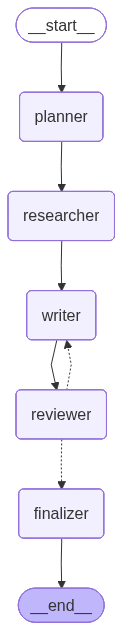

In [11]:
try:
    from IPython.display import Image, display
    display(Image(multi_agent_graph.get_graph().draw_mermaid_png()))
except Exception as exc:
    print("No se pudo renderizar el grafo como imagen.")
    print(type(exc).__name__, exc)
    print(multi_agent_graph.get_graph().draw_mermaid())

## 4. Agente con herramientas

LangGraph tambien se usa para agentes que deciden si necesitan llamar herramientas. El patron basico es:

`assistant -> tools -> assistant -> END`

`tools_condition` mira el ultimo mensaje: si contiene llamadas a herramientas, enruta al nodo `tools`; si no, termina.

In [12]:
AIRCRAFT_DB = {
    "EC-LLM": {"type": "Cessna 172", "hours": 1830, "last_inspection_days": 21, "open_findings": 0},
    "EC-RAG": {"type": "Piper PA-28", "hours": 2415, "last_inspection_days": 67, "open_findings": 2},
    "EC-GPT": {"type": "Diamond DA40", "hours": 920, "last_inspection_days": 12, "open_findings": 1},
}

@tool
def get_aircraft_status(registration: str) -> dict:
    """Consulta el estado de una aeronave de entrenamiento por matricula."""
    registration = registration.upper().strip()
    aircraft = AIRCRAFT_DB.get(registration)
    if aircraft is None:
        return {"found": False, "registration": registration}
    return {"found": True, "registration": registration, **aircraft}

@tool
def estimate_takeoff_distance(mass_kg: float, headwind_kt: float = 0) -> dict:
    """Calcula una estimacion didactica y simplificada de distancia de despegue."""
    base_distance_m = 260
    mass_factor = mass_kg / 1000
    wind_factor = max(0.75, 1 - headwind_kt * 0.015)
    distance = base_distance_m * mass_factor * wind_factor
    return {
        "distance_m": round(distance, 1),
        "warning": "Estimacion docente simplificada; no usar para operacion real.",
    }

tool_list = [get_aircraft_status, estimate_takeoff_distance]
tool_llm = llm.bind_tools(tool_list)

def tool_assistant(state: MessagesState):
    system = SystemMessage(content=(
        "Eres un asistente docente de operaciones aeronauticas. "
        "Usa herramientas si hacen falta datos. No presentes calculos como validos para vuelo real."
    ))
    response = tool_llm.invoke([system, *state["messages"]])
    return {"messages": [response]}

tool_builder = StateGraph(MessagesState)
tool_builder.add_node("assistant", tool_assistant)
tool_builder.add_node("tools", ToolNode(tool_list))

tool_builder.add_edge(START, "assistant")
tool_builder.add_conditional_edges("assistant", tools_condition)
tool_builder.add_edge("tools", "assistant")

tool_graph = tool_builder.compile()

tool_result = tool_graph.invoke({
    "messages": [HumanMessage(content="Consulta EC-RAG y estima distancia de despegue para 1100 kg con 8 kt de viento de cara.")]
})

show(tool_result["messages"][-1].content)

**Estado de la aeronave (EC-RAG):**   - Aeronave: **Piper PA-28**   - Horas: **2415 h**   -
Última inspección: **67 días**   - Hallazgos abiertos: **2**  **Estimación didáctica de
distancia de despegue (1100 kg, viento de cara 8 kt):**   - **≈ 251.7 m**    > ⚠️ Nota: esta
distancia es **una estimación docente simplificada** y **no debe usarse para operación real**.


## 5. Memoria corta con checkpointer

Un checkpointer permite conservar el estado entre llamadas usando un `thread_id`. Aqui usamos memoria en proceso con `InMemorySaver`.

In [13]:
memory = InMemorySaver()
tool_graph_with_memory = tool_builder.compile(checkpointer=memory)

config = {"configurable": {"thread_id": "demo-langgraph-1"}}

first = tool_graph_with_memory.invoke(
    {"messages": [HumanMessage(content="Estoy preparando una practica con la aeronave EC-LLM.")]},
    config=config,
)
show(first["messages"][-1].content)

second = tool_graph_with_memory.invoke(
    {"messages": [HumanMessage(content="Consulta su estado y resumelo en una frase.")]},
    config=config,
)
show(second["messages"][-1].content)

¡Perfecto! Para ayudarte a preparar la práctica con la aeronave **EC-LLM**, dime qué necesitas
exactamente:  1) **¿Qué tipo de práctica** es? (p. ej., pre-vuelo / rodaje, circuitos,
aproximación y aterrizaje, procedimientos de motor, navegación básica, emergencias, etc.)   2)
**Condiciones previstas**: pista/aeródromo, viento estimado (o “sin dato”), elevación, y si
habrá lluvia/contaminación.   3) **Tu objetivo didáctico**: ¿qué maniobras quieres que el
alumno domine y con qué criterios?    Si quieres, antes también puedo **consultar el estado**
de la aeronave por matrícula (EC-LLM). ¿Te va bien que lo revise?
La aeronave **EC-LLM (Cessna 172)** figura **en estado OK**, con **0 hallazgos abiertos** y
**última inspección hace 21 días**.


## 6. Ejecutar paso a paso con streaming

Para depurar un grafo, `stream` permite ver las actualizaciones que produce cada nodo.

In [14]:
for event in multi_agent_graph.stream({
    "topic": "como evaluar un agente con herramientas",
    "audience": "alumnos que ya conocen prompting basico",
}):
    node_name = next(iter(event.keys()))
    print("Nodo ejecutado:", node_name)
    print("Claves actualizadas:", list(event[node_name].keys()))
    print()

Nodo ejecutado: planner
Claves actualizadas: ['plan', 'revision_count']

Nodo ejecutado: researcher
Claves actualizadas: ['research']

Nodo ejecutado: writer
Claves actualizadas: ['draft']

Nodo ejecutado: reviewer
Claves actualizadas: ['status', 'review', 'revision_count']

Nodo ejecutado: finalizer
Claves actualizadas: ['final_answer']



## 7. Cierre

Ideas principales:

- LangGraph sirve para controlar flujos con estado, no solo para encadenar prompts.
- Cada agente puede modelarse como un nodo con una responsabilidad clara.
- Las aristas condicionales permiten bucles, aprobaciones, rutas alternativas y paradas.
- `ToolNode` implementa el patron comun de ejecutar herramientas solicitadas por el modelo.
- Los checkpointers permiten mantener memoria por conversacion o ejecucion.
- En produccion conviene limitar iteraciones, registrar trazas, validar herramientas y anadir evaluaciones.